In [1]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as nd

import astropy.io.fits as pyfits
import astropy.units as u

import sep

import grizli
from grizli import utils
print(f'grizli version: {grizli.__version__}')

import msaexp
import msaexp.spectrum
print(f'msaexp version: {msaexp.__version__}')

BASE_URL = 'https://s3.amazonaws.com/msaexp-nirspec/extractions/'
PATH_TO_FILE = BASE_URL + '{root}/{file}'

grizli version: 1.14.2
msaexp version: 0.9.17


In [2]:
def resampling_spectra(filename):
    from astropy import units as u
    import numpy as np
    from astropy.visualization import quantity_support
    quantity_support()  # for getting units on the axes below

    specs = msaexp.spectrum.get_spectra(
        file = filename, 
        sx=8, sy=2,
        ny=4, renorm = False
    )


    delta_tryout = 0.0006000000000000449

    common_wave = (
        np.arange(0.55, 5.509904761905082 + delta_tryout, delta_tryout) * u.um
    )

    from specutils.manipulation import FluxConservingResampler
    resampler = FluxConservingResampler()

    resampled = []

    for spec in specs:

        resamp = resampler.resample1d(spec, common_wave)

        resampled.append(resamp)

    return resampled

resampled = resampling_spectra("aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits")

https://grizli-cutout.herokuapp.com/nirspec_extractions?file=aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits&output=csv
aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits (True) 2.4832  grade=3


In [10]:
def weighted_average(resampled):

    from specutils import Spectrum
    from astropy.nddata import InverseVariance, StdDevUncertainty

    fluxes = np.array([
            resamp.flux.value for resamp in resampled
    ])

    ivars = np.array([
            resamp.uncertainty.represent_as(InverseVariance).array for resamp in resampled
    ])

    valid = (
        np.isfinite(fluxes) &
        np.isfinite(ivars) &
        (fluxes != 0) & 
        (ivars > 0)
    )

    weights = np.where(valid, ivars, 0)
    flux_valid = np.where(valid, fluxes, 0)

    weight_sum = np.sum(weights, axis = 0)
    weighted_flux = np.full(fluxes.shape[1], np.nan)

    has_data = weight_sum > 0

    weighted_flux[has_data] = (
        np.sum(weights[:, has_data] * flux_valid[:, has_data], axis = 0)/weight_sum[has_data]
    )

    weighted_std = np.full_like(weighted_flux, np.nan)

    weighted_std[has_data] = 1 / np.sqrt(weight_sum[has_data])

    z = resampled[0].meta['z']

    combined_spectrum = Spectrum(
        flux = weighted_flux * resampled[0].flux.unit,
        spectral_axis = resampled[0].spectral_axis/(1 + z),
        uncertainty = StdDevUncertainty(weighted_std * resampled[0].flux.unit), 
        meta = {'z': resampled[0].meta['z']}
    )

    return combined_spectrum

tryout = weighted_average(resampled)

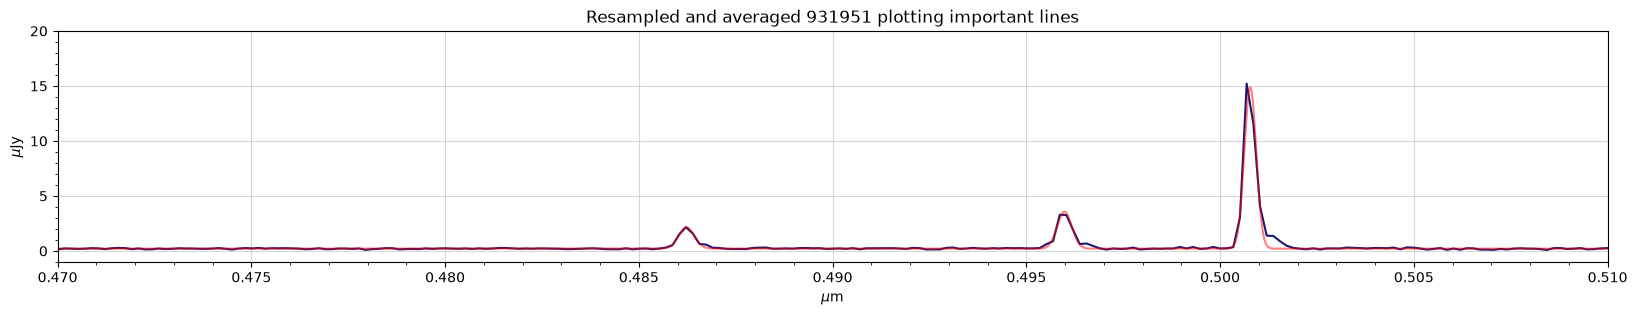

In [35]:
from scipy.optimize import curve_fit
from astropy.nddata import StdDevUncertainty

def gauss(x, mean, sigma, amplitude):
    gaussian = amplitude * np.exp((-(x - mean)**2) / (2* sigma**2))
    return gaussian

def test_model(x, a, b, 
               mean_hb, sigma_hb, amp_hb, 
               mean_Oiii1, sigma_Oiii1, amp_Oiii1, 
               mean_Oiii2, sigma_Oiii2, amp_Oiii2):

    cont = a + b*x

    return (
        cont 
        + gauss(x, mean_hb, sigma_hb, amp_hb)
        + gauss(x, mean_Oiii1, sigma_Oiii1, amp_Oiii1)
        + gauss(x, mean_Oiii2, sigma_Oiii2, amp_Oiii2)
        )




center = 0.500 * u.um
window = 0.05 * u.um

mask = (
    (tryout.spectral_axis >= center - window) &
    (tryout.spectral_axis <= center + window)
)

wave_subset = tryout.spectral_axis[mask]
flux_subset = tryout.flux[mask]
flux_err_subset = tryout.uncertainty.represent_as(StdDevUncertainty).array[mask]

initial = [0.2, 1, 
           0.4860, 0.001, 2.5, 
           0.4967, 0.001, 4, 
           0.5006, 0.001, 15]

popt, pcov = curve_fit(test_model, wave_subset.value, flux_subset.value, p0 = initial, 
                       sigma = flux_err_subset, absolute_sigma = True)



f, ax = plt.subplots(figsize = (20, 3))

ax.plot(wave_subset.value, flux_subset.value, color = 'midnightblue')

wave_model = np.linspace(
    wave_subset.value.min(),
    wave_subset.value.max(),
    5000
)

flux_model = test_model(wave_model, *popt)

ax.plot(wave_model, flux_model, color = 'r', alpha = 0.5)
ax.minorticks_on()
    
ax.set_xlabel(r'$\mu$m')
ax.set_ylabel(r'$\mu$Jy')
ax.set_xlim(0.47, 0.51)
ax.set_ylim(-1, 20)
ax.set_title('Resampled and averaged 931951 plotting important lines')
ax.grid(alpha = 0.5)
plt.show()


In [ ]:
intercept, slope, mu_hb, sig_hb, amp_hb, mu_4959, sig_4959, amp_4959, mu_5007, sig_5007, amp_5007 = popt

tryout_dict = {
    'intercept': intercept, 
    'mu_hb': mu_hb, 
    'sig_hb': sig_hb,
    'amp_hb': amp_hb,
    'mu_4959': mu_4959,
    'sig_4959': sig_4959,
    'amp_4959': amp_4959,
    'mu_5007': mu_5007,
    'sig_5007': sig_5007,
    'amp_5007': amp_5007
}

print(mu_5007)
int_5007 = amp_5007 * np.sqrt(np.pi* 2 * sig_5007**2)
int_5007 # (This is in uJy! I would want it in 10^-20 erg/s/cm2 to actually be able to compare to the measurement given by msaexp)

0.5007786466168375


0.0056083416795096154